<a href="https://colab.research.google.com/github/muskan524/eshoping/blob/master/DL_practicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Loading and visualising the MNIST Handwritten Digit Dataset


##library




In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


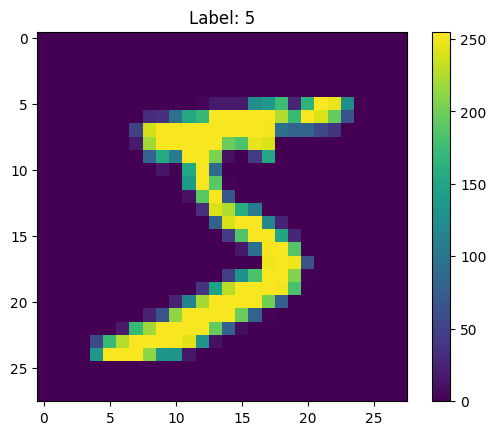

In [ ]:
plt.imshow(X_train[0])
plt.title("Label: " + str(y_train[0]))
plt.colorbar()
plt.show()

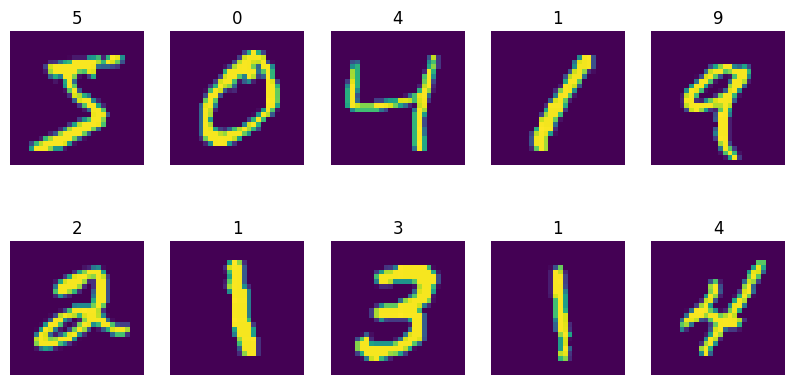

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

*italicized text*# New Section

# 2.Classification of MNIST handwritten digit



In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
# load the dataset
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
# Normalize the dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Build the Neural Network Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the model
model.fit(
    X_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9273 - loss: 0.2576
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9661 - loss: 0.1158
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9766 - loss: 0.0782
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9814 - loss: 0.0605
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0464


In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9775 - loss: 0.0751
Accuracy: 0.9775000214576721


In [ ]:
# Predict a digt
predictions = model.predict(X_test)

print("Predicted digit:",
      predictions[0].argmax())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted digit: 7


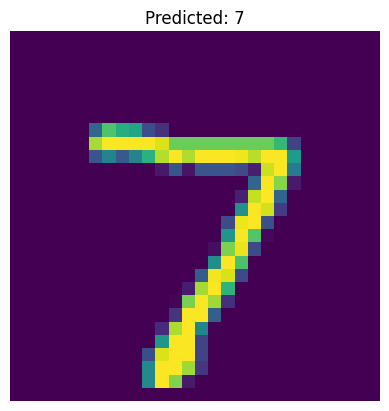

In [ ]:
# Display teh pridicted image
plt.imshow(X_test[0])
plt.title("Predicted: " +
          str(predictions[0].argmax()))
plt.axis("off")
plt.show()

# 3.Developing a binary classification model fro disease risk prediction using ANN



In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# load the dataset
data = pd.read_csv(
    "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
)

print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
# Separate Features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6466 - loss: 0.6866
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 0.6656
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6629 - loss: 0.6455 
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6661 - loss: 0.6255
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6808 - loss: 0.6041 
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7068 - loss: 0.5835 
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7231 - loss: 0.5643 
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7231 - loss: 0.5462 
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7248 - loss: 0.5295 
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7313 - loss: 0.5150 
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7329 - loss: 0.5026
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.74

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7403 - loss: 0.5513 
Test Accuracy: 0.7402597665786743


In [ ]:
prediction = model.predict(X_test)

print(prediction[:5])
prediction = (prediction > 0.5)

print(prediction[:5])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[[0.59859806]
 [0.06226441]
 [0.07573387]
 [0.31782037]
 [0.27571997]]
[[ True]
 [False]
 [False]
 [False]
 [False]]


# 4.Image classification using CNN ,2 convolutional layer on MNIST and CIFAR-10 dataset


## CNN on MNIST

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 44ms/step - accuracy: 0.9575 - loss: 0.1425
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9859 - loss: 0.0461
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9898 - loss: 0.0325
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9925 - loss: 0.0233
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 24ms/step - accuracy: 0.9946 - loss: 0.0179


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("MNIST Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0301
MNIST Accuracy: 0.9908000230789185


## CNN on CIFAR-10


In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=10
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 35ms/step - accuracy: 0.4726 - loss: 1.4722
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6042 - loss: 1.1266
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.6460 - loss: 1.0099
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.6768 - loss: 0.9265
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.6972 - loss: 0.8692
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.7144 - loss: 0.8179
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7327 - loss: 0.7709
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7483 - loss: 0.7282
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7580 - loss: 0.6927
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.7709 - loss: 0.6567


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("CIFAR-10 Accuracy:", test_accuracy)

# 5.Handling and evaluating imbalance datausing resampling,ensemble method and custom loss function


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf

In [ ]:
# create imbalanced dataset
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    weights=[0.95, 0.05],
    random_state=42
)
# check class distribution
print(pd.Series(y).value_counts())

0    947
1     53
Name: count, dtype: int64


In [ ]:
# split the dataset into train and test data set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Handling imbalance data using Resampling technique i.e SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)
# check new distribution
print(pd.Series(y_train_resampled).value_counts())

1    759
0    759
Name: count, dtype: int64


In [ ]:
 from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
    X_train_resampled,
    y_train_resampled
)
y_pred = model.predict(X_test)

print(classification_report(
    y_test,
    y_pred
))


              precision    recall  f1-score   support

           0       0.98      0.88      0.93       188
           1       0.29      0.75      0.42        12

    accuracy                           0.88       200
   macro avg       0.64      0.82      0.67       200
weighted avg       0.94      0.88      0.90       200



In [ ]:
# Handling imbalance data using Ensemble MEthod
# use Random forest
rf_model = RandomForestClassifier()

rf_model.fit(
    X_train,
    y_train
)
y_pred = rf_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       188
           1       1.00      0.58      0.74        12

    accuracy                           0.97       200
   macro avg       0.99      0.79      0.86       200
weighted avg       0.98      0.97      0.97       200



In [ ]:
# Handling Imbalance using Custom Loss function
def weighted_binary_crossentropy(y_true, y_pred):

    weights = 5

    loss = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return loss * weights

In [ ]:
# build neural network
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(10,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
# compile with custom loss
model.compile(
    optimizer='adam',
    loss=weighted_binary_crossentropy,
    metrics=['accuracy']
)
# train the model
model.fit(
    X_train,
    y_train,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1750 - loss: 4.9995
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4162 - loss: 3.9655
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6963 - loss: 3.1726 
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8213 - loss: 2.5801 
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9112 - loss: 2.1292 
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9375 - loss: 1.7879 
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9525 - loss: 1.5372 
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9563 - loss: 1.3431 
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9550 - loss: 1.1975 
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9563 - loss: 1.0893 


In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(
    y_test,
    y_pred
))

[[188   0]
 [  5   7]]


# 6.Image data augmentation using keras


In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
# Load dataset
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Reshape and normalize image
X_train = X_train.reshape(-1, 28, 28, 1)
X_train = X_train / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Create Data Augmentation Generator
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
# This step prepares the generator to apply transformation
datagen.fit(X_train)

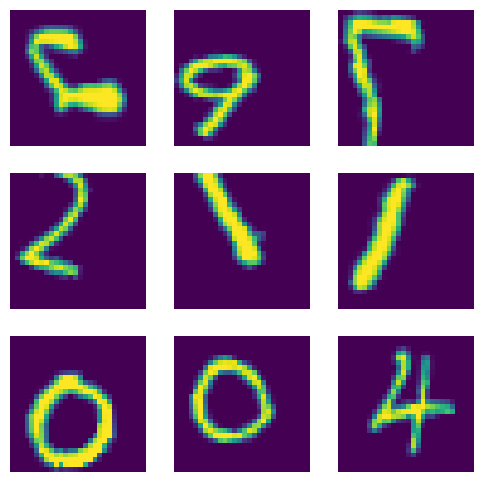

In [ ]:

# Generate Augmented Images
for X_batch, y_batch in datagen.flow(
        X_train,
        y_train,
        batch_size=9):

    plt.figure(figsize=(6,6))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_batch[i].reshape(28, 28))
        plt.axis("off")

    plt.show()
    break

In [ ]:
#  train the model using augmented data
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28, 28, 1)
))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - accuracy: 0.7445 - loss: 0.7633
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8882 - loss: 0.3520
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9164 - loss: 0.2653
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 23ms/step - accuracy: 0.9297 - loss: 0.2230
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9363 - loss: 0.2022


# 7.Implementation of ANN using backpropagation with different activation function


In [ ]:
# import libraries
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"

columns = [
    'Pregnancies','Glucose','BloodPressure',
    'SkinThickness','Insulin','BMI',
    'DiabetesPedigreeFunction','Age','Outcome'
]

data = pd.read_csv(url, names=columns)


In [ ]:
# Split Feature and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Build ANN model (using relu)
model = Sequential()

model.add(Dense(
    16,
    activation='relu',
    input_shape=(8,)
))

model.add(Dense(
    8,
    activation='relu'
))

model.add(Dense(
    1,
    activation='sigmoid'
))
# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", test_accuracy)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6945 - loss: 0.5855 - val_accuracy: 0.6829 - val_loss: 0.6135
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6945 - loss: 0.5704 - val_accuracy: 0.6829 - val_loss: 0.5978
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7047 - loss: 0.5577 - val_accuracy: 0.6911 - val_loss: 0.5841
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7088 - loss: 0.5458 - val_accuracy: 0.7073 - val_loss: 0.5757
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7189 - loss: 0.5354 - val_accuracy: 0.7154 - val_loss: 0.5642
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7332 - loss: 0.5248 - val_accuracy: 0.7398 - val_loss: 0.5545
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7373 - loss: 0.5156 - val_accuracy: 0.7398 - val_loss: 0.5461
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7495 - loss: 0.5067 - val_accuracy: 0.7480 - val_loss: 0.5

In [ ]:
model.add(Dense(
    16,
    activation='tanh',
    input_shape=(8,)
))

model.add(Dense(
    8,
    activation='tanh'
))

model.add(Dense(
    1,
    activation='sigmoid'
))
# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", test_accuracy)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6640 - loss: 0.6787 - val_accuracy: 0.6098 - val_loss: 0.6744
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6640 - loss: 0.6550 - val_accuracy: 0.6098 - val_loss: 0.6689
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6431 - val_accuracy: 0.6098 - val_loss: 0.6712
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6640 - loss: 0.6389 - val_accuracy: 0.6098 - val_loss: 0.6739
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6383 - val_accuracy: 0.6098 - val_loss: 0.6737
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6370 - val_accuracy: 0.6098 - val_loss: 0.6726
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6347 - val_accuracy: 0.6098 - val_loss: 0.6739
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6319 - val_accuracy: 0.6098 - val_los

In [ ]:
model.add(Dense(
    16,
    activation='sigmoid',
    input_shape=(8,)
))

model.add(Dense(
    8,
    activation='sigmoid'
))

model.add(Dense(
    1,
    activation='sigmoid'
))
# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", test_accuracy)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6640 - loss: 0.6852 - val_accuracy: 0.6098 - val_loss: 0.7405
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6640 - loss: 0.6643 - val_accuracy: 0.6098 - val_loss: 0.7152
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6640 - loss: 0.6495 - val_accuracy: 0.6098 - val_loss: 0.6990
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6640 - loss: 0.6425 - val_accuracy: 0.6098 - val_loss: 0.6865
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6640 - loss: 0.6376 - val_accuracy: 0.6098 - val_loss: 0.6812
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6640 - loss: 0.6355 - val_accuracy: 0.6098 - val_loss: 0.6765
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6640 - loss: 0.6340 - val_accuracy: 0.6098 - val_loss: 0.6741
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6640 - loss: 0.6326 - val_accuracy: 0.6098 - va

# 8.Implementation of deep feed forward ANN with 4 hidden layer backpropagation


In [ ]:
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"

columns = [
    'Pregnancies','Glucose','BloodPressure',
    'SkinThickness','Insulin','BMI',
    'DiabetesPedigreeFunction','Age','Outcome'
]

data = pd.read_csv(url, names=columns)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential()

# Hidden Layer 1
model.add(Dense(
    32,
    activation='relu',
    input_shape=(8,)
))

# Hidden Layer 2
model.add(Dense(
    16,
    activation='relu'
))

# Hidden Layer 3
model.add(Dense(
    8,
    activation='relu'
))

# Hidden Layer 4
model.add(Dense(
    4,
    activation='relu'
))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6640 - loss: 0.6581 - val_accuracy: 0.6179 - val_loss: 0.6753
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6308 - val_accuracy: 0.6260 - val_loss: 0.6548
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6680 - loss: 0.6047 - val_accuracy: 0.6179 - val_loss: 0.6336
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6660 - loss: 0.5802 - val_accuracy: 0.6260 - val_loss: 0.6135
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6741 - loss: 0.5587 - val_accuracy: 0.6260 - val_loss: 0.5971
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6782 - loss: 0.5377 - val_accuracy: 0.6179 - val_loss: 0.5784
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6925 - loss: 0.5217 - val_accuracy: 0.6667 - val_loss: 0.5612
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7047 - loss: 0.5074 - val_accuracy: 0.6667 - val_loss: 0.5472
Ep

#   9.Time series forcasting using deep learning network using LSTM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [ ]:
data = np.array([
    100,110,120,130,140,
    150,160,170,180,190,
    200,210,220,230,240
])
data = pd.DataFrame(data, columns=["Value"])
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)
def create_dataset(data, time_step=3):

    X = []
    y = []

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])

    return np.array(X), np.array(y)
time_step = 3

X, y = create_dataset(
    scaled_data,
    time_step
)
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)

(9, 3, 1)


# 10.Image data comparison using autoencoder neural network on CIf

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 240s 1us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape : (10000, 32, 32, 3)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 0.5754 - val_loss: 0.5630
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5607 - val_loss: 0.5600
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5587 - val_loss: 0.5587
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5576 - val_loss: 0.5578
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5570 - val_loss: 0.5602
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5564 - val_loss: 0.5568
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5560 - val_loss: 0.5564
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5556 - val_loss: 0.5562
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5553 - val_loss: 0.5559
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5549 - val_loss: 0.5554
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


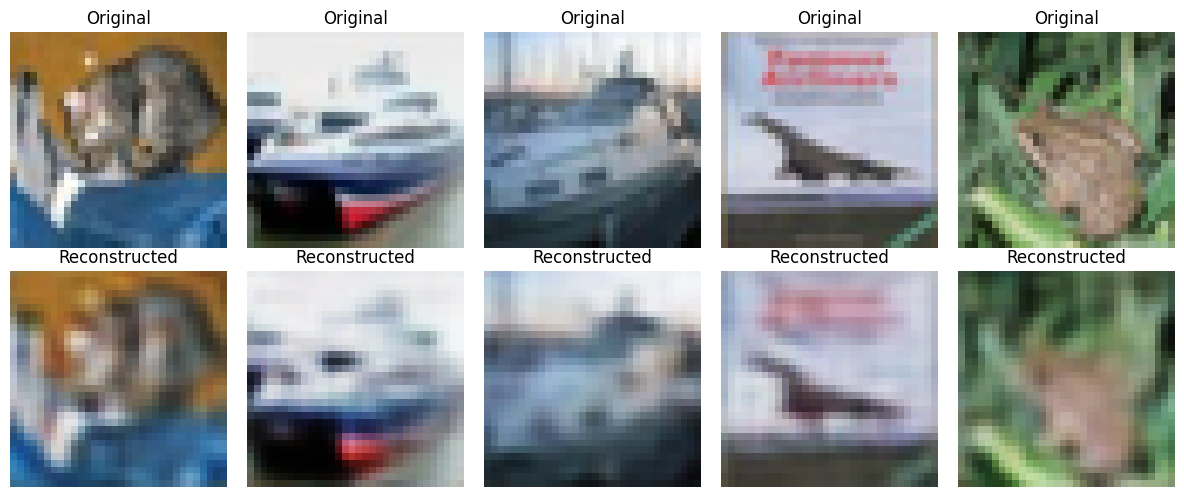


Reconstruction Error (MSE): 0.0029038098


In [ ]:
# ==========================================================
# IMAGE DATA COMPARISON USING AUTOENCODER NEURAL NETWORK
# CIFAR-10 DATASET (Deep Learning Practical)
# ==========================================================

# Install if needed:
# pip install tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.optimizers import Adam

# ==========================================================
# 1. LOAD CIFAR-10 DATASET
# ==========================================================

(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize images (0 to 1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

# ==========================================================
# 2. BUILD AUTOENCODER MODEL
# ==========================================================

input_img = Input(shape=(32, 32, 3))

# ---------------- ENCODER ----------------

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# ---------------- DECODER ----------------

x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

# Create model
autoencoder = Model(input_img, decoded)

# ==========================================================
# 3. COMPILE MODEL
# ==========================================================

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

autoencoder.summary()

# ==========================================================
# 4. TRAIN MODEL
# ==========================================================

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# ==========================================================
# 5. RECONSTRUCT TEST IMAGES
# ==========================================================

decoded_imgs = autoencoder.predict(x_test)

# ==========================================================
# 6. IMAGE DATA COMPARISON
# ORIGINAL VS RECONSTRUCTED
# ==========================================================

n = 5   # Number of images to display

plt.figure(figsize=(12,5))

for i in range(n):

    # ---------------- ORIGINAL IMAGE ----------------
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

    # ---------------- RECONSTRUCTED IMAGE ----------------
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================================
# 7. CALCULATE RECONSTRUCTION ERROR
# ==========================================================

mse = np.mean(np.square(x_test - decoded_imgs))

print("\nReconstruction Error (MSE):", mse)

# ==========================================================
# END OF PRACTICAL
# ==========================================================